# Nutria — Eval Dashboard

Compara experimentos de avaliação do agente Nutria.  
Dados carregados direto da API do Catalog (`http://localhost:8000`).


In [26]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.float_format", "{:.3f}".format)

CATALOG_URL = "http://localhost:8000"
METRICS = ["faithfulness", "answer_relevancy", "context_relevancy", "context_recall", "context_precision", "overall_score"]
METRIC_LABELS = {
    "faithfulness":      "Faithfulness",
    "answer_relevancy":  "Answer Relevancy",
    "context_relevancy": "Context Relevancy",
    "context_recall":    "Context Recall",
    "context_precision": "Context Precision",
    "overall_score":     "Overall Score",
}


## 1. Carregar experimentos

In [27]:
def load_experiments():
    resp = requests.get(f"{CATALOG_URL}/api/v1/eval/experiments")
    resp.raise_for_status()
    return resp.json()["experiments"]

def load_runs(experiment_id):
    resp = requests.get(f"{CATALOG_URL}/api/v1/eval/experiments/{experiment_id}")
    resp.raise_for_status()
    return resp.json()["runs"]

def build_runs_df(experiments):
    rows = []
    for exp in experiments:
        if exp["run_count"] == 0:
            continue
        runs = load_runs(exp["id"])
        for i, run in enumerate(runs):
            result = run.get("result") or {}
            rows.append({
                "experiment_id":   exp["id"],
                "experiment":      exp["name"],
                "retrieval_source": (exp.get("params") or {}).get("retrieval_source", "?"),
                "dataset":         (exp.get("params") or {}).get("dataset_filename", "?"),
                "run_index":       i + 1,
                "question":        run["question"],
                "question_short":  run["question"][:55] + "…" if len(run["question"]) > 55 else run["question"],
                "answer":          run.get("answer"),
                "expected_answer": run.get("expected_answer"),
                "latency_ms":      run.get("latency_ms"),
                **{m: result.get(m) for m in METRICS},
            })
    return pd.DataFrame(rows)

experiments = load_experiments()
df = build_runs_df(experiments)

print(f"Experimentos com runs: {df['experiment'].nunique()}")
print(f"Total de runs: {len(df)}")
df.head(3)


Experimentos com runs: 9
Total de runs: 250


,experiment_id,experiment,retrieval_source,dataset,run_index,question,question_short,answer,expected_answer,latency_ms,faithfulness,answer_relevancy,context_relevancy,context_recall,context_precision,overall_score
0,acbdd9f0-a61a-4823-81ad-e6d50b547893,OVERFITTING_EXPERIMENTS_PROMPT_V2,json,overfitting_dataset.json,1,Quantos gramas de carboidrato tem em 200g de m...,Quantos gramas de carboidrato tem em 200g de m...,Não encontrei especificamente o macarrão integ...,NaN,27121,0.784,0.935,None,NaN,NaN,0.833
1,acbdd9f0-a61a-4823-81ad-e6d50b547893,OVERFITTING_EXPERIMENTS_PROMPT_V2,json,overfitting_dataset.json,2,Qual é o teor de cálcio em 100g de queijo mina...,Qual é o teor de cálcio em 100g de queijo mina...,"Em 100g de queijo minas frescal, há aproximada...",NaN,22263,0.791,0.938,None,NaN,NaN,0.837
2,acbdd9f0-a61a-4823-81ad-e6d50b547893,OVERFITTING_EXPERIMENTS_PROMPT_V2,json,overfitting_dataset.json,3,Quantas calorias tem uma colher de sopa de aze...,Quantas calorias tem uma colher de sopa de aze...,[Error: Server error '500 Internal Server Erro...,NaN,0,NaN,NaN,None,NaN,NaN,NaN


## 2. Tabela comparativa entre experimentos

Média de cada métrica por experimento, ordenado por `overall_score`.


In [28]:
summary = (
    df.groupby(["experiment", "retrieval_source", "dataset"])[METRICS]
    .mean()
    .reset_index()
    .sort_values("overall_score", ascending=False)
)

# Color cells: green = high, red = low
def color_score(val):
    if pd.isna(val): return ""
    if val >= 0.8:   return "background-color: #c8f0c8"
    if val >= 0.6:   return "background-color: #fff3c4"
    return "background-color: #f8c8c8"

summary.style.map(color_score, subset=METRICS).format({m: "{:.3f}" for m in METRICS})


,experiment,retrieval_source,dataset,faithfulness,answer_relevancy,context_relevancy,context_recall,context_precision,overall_score
1,OVERFITTING_EXPERIMENTS_PROMPT_V2,json,overfitting_dataset.json,0.790,0.927,nan,nan,nan,0.839
8,prompt_v2_tools_refactor,json,golden_dataset.json,0.782,0.925,nan,0.793,0.000,0.749
0,FIX_ALPHANUMERIC_SEARCH_RETRIEVAL_JSON,json,golden_dataset.json,0.793,0.930,nan,0.799,0.000,0.744
2,prompt v2 tool refactor ingested,pdf,golden_dataset.json,0.799,0.916,nan,0.799,0.000,0.742
3,prompt_padrao_v1,json,golden_dataset.json,0.096,0.613,nan,-0.017,0.000,0.282
7,prompt_v2_multilingual,json,golden_dataset.json,0.178,0.700,nan,0.029,0.000,0.249
5,prompt_padrao_v1_tools,json,golden_dataset.json,0.344,0.426,nan,-0.033,0.000,0.213
4,prompt_padrao_v1_10,json,golden_dataset.json,0.118,0.592,nan,-0.037,0.000,0.184
6,prompt_v1_10_tools,json,golden_dataset.json,0.067,0.635,nan,-0.039,0.000,0.179


## 3. Comparação visual — Overall Score por experimento

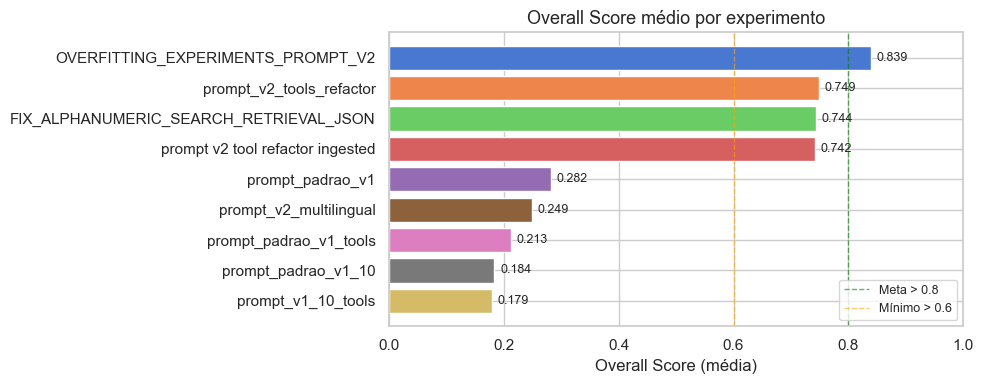

In [29]:
fig, ax = plt.subplots(figsize=(10, 4))

colors = sns.color_palette("muted", n_colors=len(summary))
bars = ax.barh(summary["experiment"], summary["overall_score"], color=colors)

ax.set_xlabel("Overall Score (média)")
ax.set_xlim(0, 1)
ax.axvline(0.8, color="green", linestyle="--", linewidth=1, alpha=0.6, label="Meta > 0.8")
ax.axvline(0.6, color="orange", linestyle="--", linewidth=1, alpha=0.6, label="Mínimo > 0.6")
ax.legend(fontsize=9)
ax.bar_label(bars, fmt="%.3f", padding=4, fontsize=9)
ax.invert_yaxis()
ax.set_title("Overall Score médio por experimento", fontsize=13)

plt.tight_layout()
plt.show()


## 4. Radar de métricas por experimento

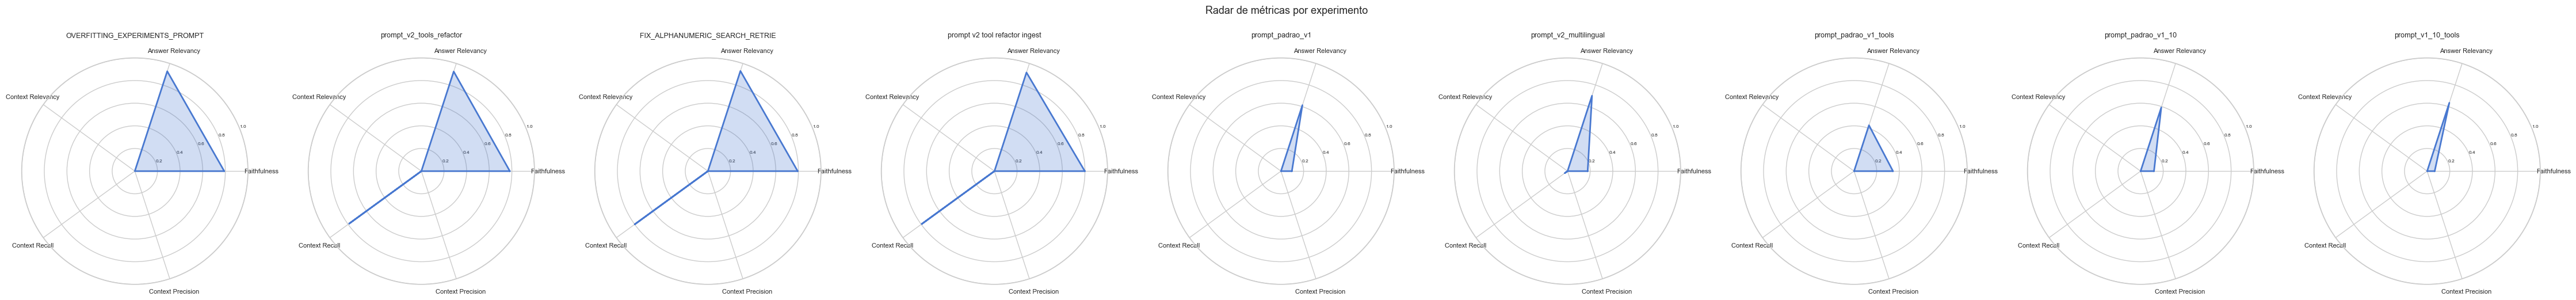

In [30]:
import numpy as np

radar_metrics = ["faithfulness", "answer_relevancy", "context_relevancy", "context_recall", "context_precision"]
labels = [METRIC_LABELS[m] for m in radar_metrics]
N = len(radar_metrics)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, axes = plt.subplots(
    1, len(summary), figsize=(5 * len(summary), 5),
    subplot_kw=dict(polar=True)
)
if len(summary) == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, summary.iterrows()):
    values = [row[m] if not pd.isna(row[m]) else 0 for m in radar_metrics]
    values += values[:1]

    ax.plot(angles, values, linewidth=2, linestyle="solid")
    ax.fill(angles, values, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=6)
    ax.set_title(row["experiment"][:30], fontsize=9, pad=14)

plt.suptitle("Radar de métricas por experimento", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 5. Heatmap — métricas por pergunta

Escolha o experimento pelo nome abaixo.


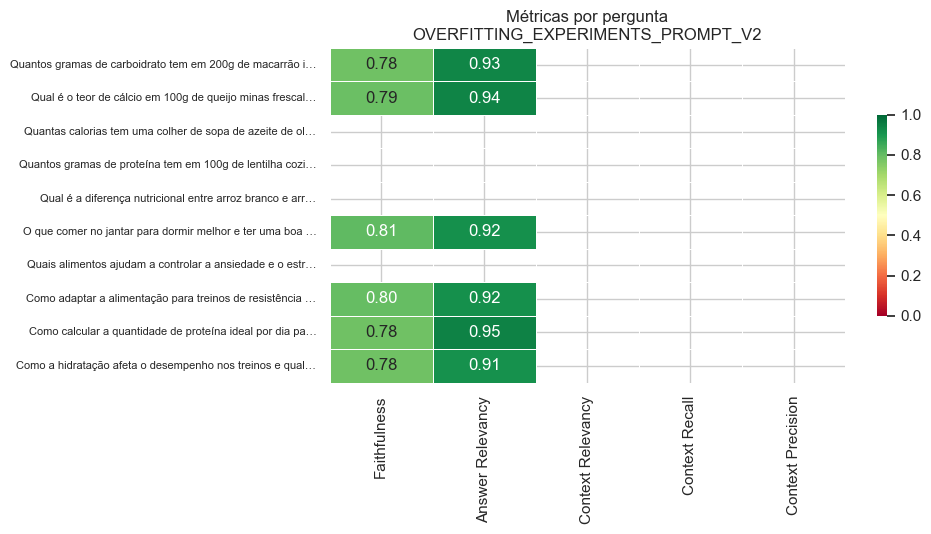

In [31]:
# Troque pelo nome do experimento que quer inspecionar
EXPERIMENT_NAME = df["experiment"].iloc[0]

exp_df = df[df["experiment"] == EXPERIMENT_NAME].copy()
heat = exp_df.set_index("question_short")[["faithfulness", "answer_relevancy", "context_relevancy", "context_recall", "context_precision"]]
heat.columns = [METRIC_LABELS[c] for c in heat.columns]

fig, ax = plt.subplots(figsize=(10, max(4, len(heat) * 0.55)))
sns.heatmap(
    heat.astype(float),
    annot=True, fmt=".2f",
    cmap="RdYlGn", vmin=0, vmax=1,
    linewidths=0.5, ax=ax,
    cbar_kws={"shrink": 0.6}
)
ax.set_title(f"Métricas por pergunta\n{EXPERIMENT_NAME}", fontsize=12)
ax.set_ylabel("")
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()


## 6. Latência por experimento

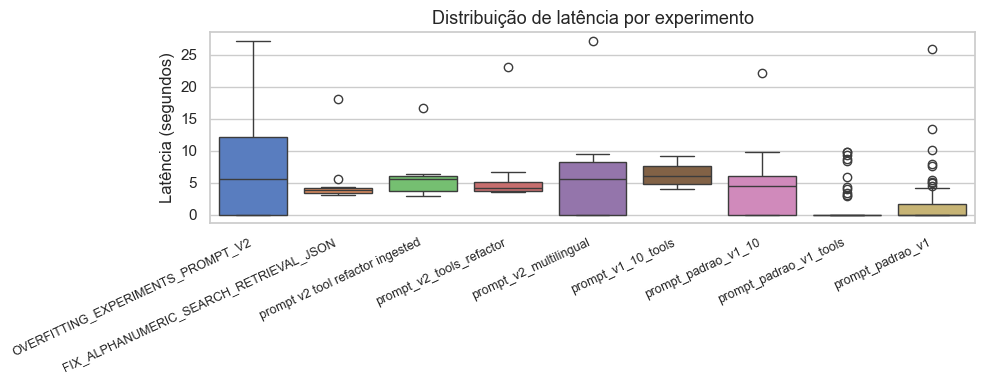

,mean,median,max
experiment,,,
FIX_ALPHANUMERIC_SEARCH_RETRIEVAL_JSON,5.260,3.800,18.120
OVERFITTING_EXPERIMENTS_PROMPT_V2,8.070,5.560,27.120
prompt v2 tool refactor ingested,6.020,5.510,16.660
prompt_padrao_v1,1.470,0.000,25.840
prompt_padrao_v1_10,4.590,4.470,22.080
prompt_padrao_v1_tools,1.160,0.000,9.830
prompt_v1_10_tools,6.270,6.060,9.180
prompt_v2_multilingual,5.600,5.610,27.050
prompt_v2_tools_refactor,6.230,4.150,23.000


In [32]:
lat = df.dropna(subset=["latency_ms"]).copy()
lat["latency_s"] = lat["latency_ms"] / 1000

fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=lat, x="experiment", y="latency_s", ax=ax, palette="muted")
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right", fontsize=9)
ax.set_ylabel("Latência (segundos)")
ax.set_xlabel("")
ax.set_title("Distribuição de latência por experimento", fontsize=13)
plt.tight_layout()
plt.show()

lat.groupby("experiment")["latency_s"].agg(["mean", "median", "max"]).round(2)


## 7. Perguntas com pior desempenho (overall_score médio)

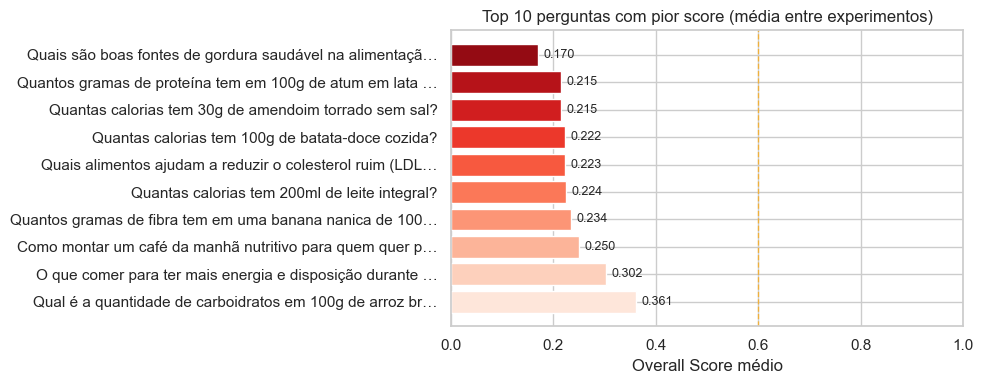

In [33]:
worst = (
    df.groupby("question_short")["overall_score"]
    .mean()
    .reset_index()
    .sort_values("overall_score")
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(worst["question_short"], worst["overall_score"], color=sns.color_palette("Reds_r", len(worst)))
ax.set_xlim(0, 1)
ax.axvline(0.6, color="orange", linestyle="--", linewidth=1, alpha=0.7)
ax.bar_label(bars, fmt="%.3f", padding=4, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Overall Score médio")
ax.set_title("Top 10 perguntas com pior score (média entre experimentos)", fontsize=12)
plt.tight_layout()
plt.show()


## 8. Evolução do overall_score entre experimentos

Ordena os experimentos por `created_at` e mostra a evolução.


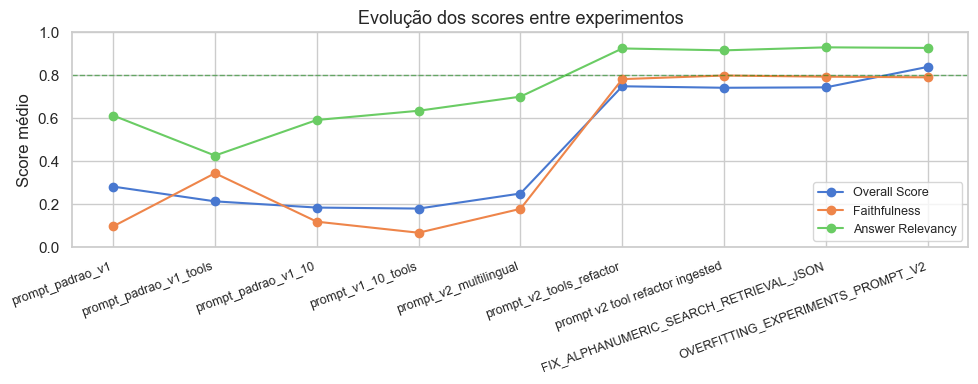

In [34]:
exp_order = (
    pd.DataFrame(experiments)
    [["id", "name", "created_at"]]
    .rename(columns={"name": "experiment"})
    .sort_values("created_at")
)

evolution = (
    summary
    .merge(exp_order[["experiment", "created_at"]], on="experiment", how="left")
    .sort_values("created_at")
)

fig, ax = plt.subplots(figsize=(10, 4))
for metric in ["overall_score", "faithfulness", "answer_relevancy"]:
    ax.plot(evolution["experiment"], evolution[metric], marker="o", label=METRIC_LABELS[metric])

ax.set_ylim(0, 1)
ax.axhline(0.8, color="green", linestyle="--", linewidth=1, alpha=0.5)
ax.set_xticklabels(evolution["experiment"], rotation=20, ha="right", fontsize=9)
ax.set_ylabel("Score médio")
ax.legend(fontsize=9)
ax.set_title("Evolução dos scores entre experimentos", fontsize=13)
plt.tight_layout()
plt.show()
